# Task 1 - EDA: Liquidation Signal Dataset (Shaw Team)

Exploratory analysis of the 3-month Binance/Bybit dataset behind the liquidation-based
trade-filtering task. We answer the four questions from the assignment:

1. **Data quality** - NaNs, duplicate / non-monotonic timestamps, bad prices & sides, crossed
   books, time gaps. For each, is it a *market feature* or a *data-quality issue*?
2. **Markout** - maker PnL (bps) at horizons tau in {30, 120, 300}s: weighted average and
   distribution, compared between the train and validation periods.
3. **Liquidations & cascades** - how to detect cascades (time-clustering) and what they look
   like; cross-exchange overlap.
4. **Turnover constraint** - the minimum share of clipped turnover needed to keep >= $500k/day.

Conventions (from `description.md`): timestamps are int64 **microseconds UTC**; trade `side`
is the **taker** side; maker PnL uses a forward-filled mid at `t + tau` plus a +0.5 bps rebate;
trade weight is `min(notional, 100_000)`; **Bybit liquidations are shifted +200 ms** before
being compared with Binance times. Split: train `2025-12-01 -> 2026-01-31`, validation
`2026-02-01 -> 2026-02-28`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("."))
DATA_ROOT = os.environ.get("SHAW_DATA_ROOT", "liquidation_task/data")

from datetime import datetime, timezone
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import eda

pl.Config.set_tbl_rows(20)
TCOLS = ["timestamp", "side", "price", "amount"]
BCOLS = ["timestamp", "bid_price", "bid_amount", "ask_price", "ask_amount"]

def load_window(folder, fname, start, end, cols):
    return (pl.scan_parquet(f"{DATA_ROOT}/{folder}/{fname}.parquet").select(cols)
            .filter((pl.col("timestamp") >= start) & (pl.col("timestamp") < end))
            .sort("timestamp").collect())

def ts(y, m, d):
    return int(datetime(y, m, d, tzinfo=timezone.utc).timestamp() * 1e6)

# Representative 2-day windows from each regime (full markout on millions of trades).
TR0, TR1 = ts(2025, 12, 1), ts(2025, 12, 3)
VA0, VA1 = ts(2026, 2, 1), ts(2026, 2, 3)
SYM = "btc"
print("data root:", DATA_ROOT)

data root: /Users/mvvm/Documents/REPS/CMF/HFT_SHAW_TEAM/liquidation_task/data


## 1. Data quality

Load a train and a validation window for BTC and run the quality checks side by side.

In [2]:
tr_trades = load_window("binance_trades", f"perp_{SYM}usdt", TR0, TR1, TCOLS)
tr_bbo    = load_window("binance_booktickers", f"perp_{SYM}usdt", TR0, TR1, BCOLS)
va_trades = load_window("binance_trades", f"perp_{SYM}usdt", VA0, VA1, TCOLS)
va_bbo    = load_window("binance_booktickers", f"perp_{SYM}usdt", VA0, VA1, BCOLS)
print("train  trades", tr_trades.height, "bbo", tr_bbo.height)
print("valid  trades", va_trades.height, "bbo", va_bbo.height)

train  trades 12088231 bbo 2548456
valid  trades 17115511 bbo 2560342


In [3]:
def quality_row(name, trades, bbo):
    th = eda.timestamp_health(trades["timestamp"].to_numpy())
    an = eda.trade_anomalies(trades)
    bq = eda.bbo_quality(bbo)
    tg = eda.time_gaps(trades["timestamp"].to_numpy())
    nan_tr = sum(eda.nan_report(trades).values())
    nan_bb = sum(eda.nan_report(bbo).values())
    return {
        "window": name, "n_trades": th["n"],
        "nan_trades": nan_tr, "nan_bbo": nan_bb,
        "dup_ts_share": round(th["n_duplicate_ts"] / th["n"], 3),
        "ts_decreasing": th["n_decreasing"],
        "nonpos_price": an["n_nonpositive_price"], "bad_side": an["n_unexpected_side"],
        "crossed_books": bq["n_crossed_bid_gt_ask"], "neg_spread": bq["n_negative_spread"],
        "spread_bps_med": round(bq["spread_bps_median"], 4),
        "trade_gap_max_s": tg["max_s"], "trade_gap_p999_s": tg["p999_s"],
    }

pl.DataFrame([quality_row("train Dec1-3", tr_trades, tr_bbo),
              quality_row("valid Feb1-3", va_trades, va_bbo)])

window,n_trades,nan_trades,nan_bbo,dup_ts_share,ts_decreasing,nonpos_price,bad_side,crossed_books,neg_spread,spread_bps_med,trade_gap_max_s,trade_gap_p999_s
str,i64,i64,i64,f64,i64,i64,i64,i64,i64,f64,f64,f64
"""train Dec1-3""",12088231,0,0,0.762,0,0,0,0,0,0.0115,3.81,0.812
"""valid Feb1-3""",17115511,0,0,0.821,0,0,0,0,0,0.0128,4.76,0.794


**Reading the table.** No NaNs, no non-positive prices, no unexpected `side` values, no
crossed/locked books and no negative spreads in either regime. Two things stand out and are
**market/feed features, not corruption**:

* **Duplicate timestamps** dominate (~0.7-0.8 of trades share a microsecond with a neighbour).
  Microsecond-stamped trades are the individual fills of one aggressive marketable order that
  sweeps several price levels / resting orders; the exchange reports them at the same
  microsecond. Timestamps are still non-decreasing, so it is safe to treat them as a stable
  event order.
* **Time gaps** are tiny (sub-second p99.9, a few seconds max) - quiet stretches of the tape,
  not missing data.

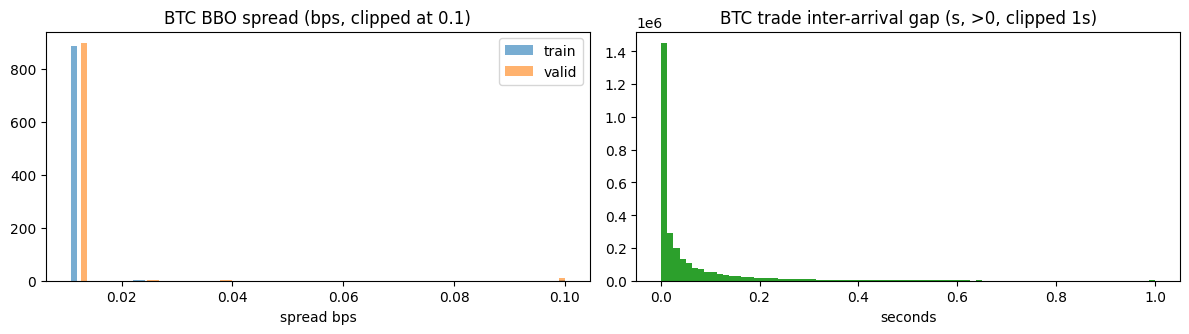

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
sp_tr = ((tr_bbo["ask_price"] - tr_bbo["bid_price"]) / ((tr_bbo["ask_price"] + tr_bbo["bid_price"]) / 2) * 1e4).to_numpy()
sp_va = ((va_bbo["ask_price"] - va_bbo["bid_price"]) / ((va_bbo["ask_price"] + va_bbo["bid_price"]) / 2) * 1e4).to_numpy()
ax[0].hist(np.clip(sp_tr, 0, 0.1), bins=80, alpha=0.6, label="train", density=True)
ax[0].hist(np.clip(sp_va, 0, 0.1), bins=80, alpha=0.6, label="valid", density=True)
ax[0].set_title("BTC BBO spread (bps, clipped at 0.1)"); ax[0].set_xlabel("spread bps"); ax[0].legend()

g_tr = np.diff(tr_trades["timestamp"].to_numpy()) / 1e6
ax[1].hist(np.clip(g_tr[g_tr > 0], 0, 1.0), bins=80, color="C2")
ax[1].set_title("BTC trade inter-arrival gap (s, >0, clipped 1s)"); ax[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 2. Markout

Maker PnL (bps) at each horizon, weighted by `min(notional, 100k)`, on the full trades of each window.

In [5]:
mk_tr = eda.compute_markout(tr_trades, tr_bbo)
mk_va = eda.compute_markout(va_trades, va_bbo)
summary = pl.concat([
    mk_tr["summary"].with_columns(pl.lit("train Dec1-3").alias("window")),
    mk_va["summary"].with_columns(pl.lit("valid Feb1-3").alias("window")),
]).select("window", "tau_s", "pnl_all_bps", "pnl_std_bps", "excluded_share")
summary

window,tau_s,pnl_all_bps,pnl_std_bps,excluded_share
str,i64,f64,f64,f64
"""train Dec1-3""",30,0.037051,8.17486,0.000062
"""train Dec1-3""",120,0.017727,15.363241,0.000225
"""train Dec1-3""",300,-0.238323,23.712052,0.000733
"""valid Feb1-3""",30,-0.222486,10.629475,0.000056
"""valid Feb1-3""",120,-0.329425,20.414714,0.00013
"""valid Feb1-3""",300,-0.16248,32.301871,0.000524


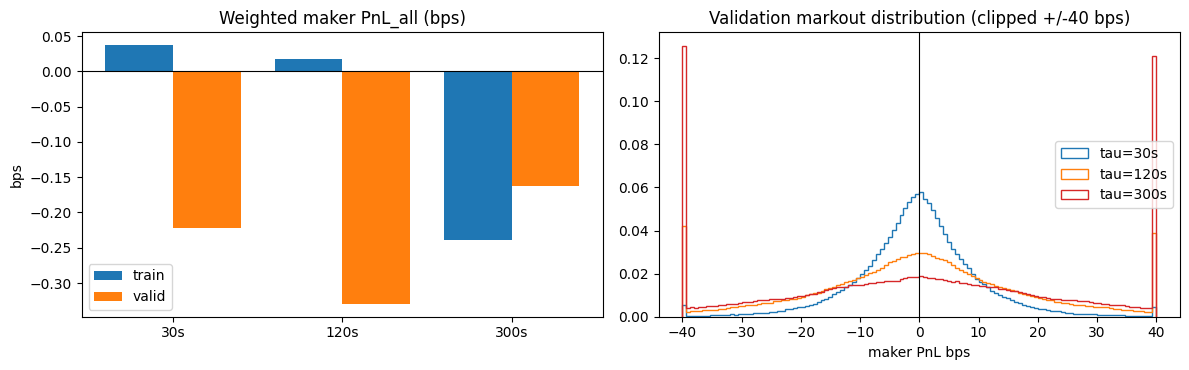

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
taus = eda.TAUS_S
x = np.arange(len(taus))
ax[0].bar(x - 0.2, [mk_tr["summary"]["pnl_all_bps"][i] for i in range(3)], 0.4, label="train")
ax[0].bar(x + 0.2, [mk_va["summary"]["pnl_all_bps"][i] for i in range(3)], 0.4, label="valid")
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_xticks(x); ax[0].set_xticklabels([f"{t}s" for t in taus])
ax[0].set_title("Weighted maker PnL_all (bps)"); ax[0].set_ylabel("bps"); ax[0].legend()

for tau, col in zip(taus, ["C0", "C1", "C3"]):
    v = mk_va["per_trade"][tau]; v = v[np.isfinite(v)]
    ax[1].hist(np.clip(v, -40, 40), bins=120, histtype="step", density=True, label=f"tau={tau}s", color=col)
ax[1].axvline(0, color="k", lw=0.8); ax[1].set_title("Validation markout distribution (clipped +/-40 bps)")
ax[1].set_xlabel("maker PnL bps"); ax[1].legend()
plt.tight_layout(); plt.show()

**Finding - a clear regime shift.** Baseline maker flow is roughly break-even / mildly
positive at short horizons in the train window but **distinctly toxic (negative PnL_all) across
horizons in validation**. The markout distribution is near-symmetric around zero with heavy
tails that fatten with tau, and the +0.5 bps rebate is what keeps the unfiltered baseline near
zero. This is exactly the setting the filter targets: drop the trades that sit in the toxic
left tail (cascade-driven adverse selection) while keeping enough turnover. The validation
month being more toxic than train means rules must be validated out-of-sample, not fit to
train.

## 3. Liquidations & cascades

Load the full (small) liquidation tables, merge venues with the +200 ms Bybit shift, and time-cluster into cascades.

In [7]:
liq_bin = pl.read_parquet(f"{DATA_ROOT}/binance_liquidations/perp_{SYM}usdt.parquet")
liq_byb = pl.read_parquet(f"{DATA_ROOT}/bybit_liquidations/{SYM}usdt.parquet")
comb = eda.combined_liquidations(liq_bin, liq_byb)
print(f"binance {liq_bin.height:,}  bybit {liq_byb.height:,}  combined {comb.height:,}")
print(f"total liquidation notional: ${comb['notional'].sum() / 1e9:.3f}B")

cascades = eda.detect_cascades(comb, gap_s=1.0, min_events=5, min_notional=1_000_000.0)
print(f"cascades detected: {cascades.height}")
print(f"multi-venue cascade share: {float((cascades['n_venues'] > 1).mean()):.3f}")
cascades.select("n_events", "total_notional", "duration_s", "buy_share", "n_venues").describe()

binance 114,255  bybit 228,655  combined 342,910
total liquidation notional: $4.205B
cascades detected: 623
multi-venue cascade share: 0.995


statistic,n_events,total_notional,duration_s,buy_share,n_venues
str,f64,f64,f64,f64,f64
"""count""",623.0,623.0,623.0,623.0,623.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",126.75923,2.8045e6,5.555674,0.300965,1.995185
"""std""",172.476784,3.3949e6,3.564443,0.458166,0.069281
"""min""",5.0,1.0015e6,0.527,0.0,1.0
"""25%""",29.0,1.3917e6,2.878,0.0,2.0
"""50%""",79.0,1.9736e6,4.98,0.0,2.0
"""75%""",152.0,2.7746e6,7.354,1.0,2.0
"""max""",1692.0,4.6451e7,22.288,1.0,2.0


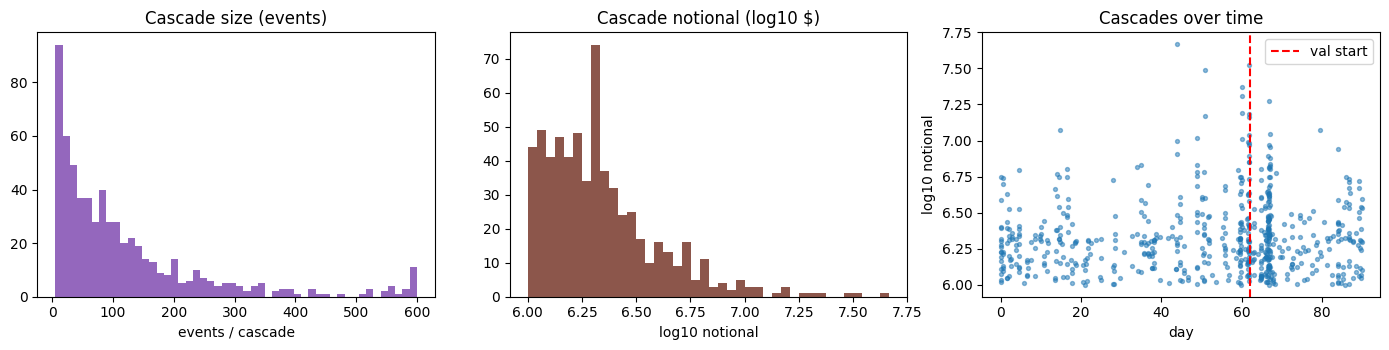

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].hist(np.clip(cascades["n_events"].to_numpy(), 0, 600), bins=50, color="C4")
ax[0].set_title("Cascade size (events)"); ax[0].set_xlabel("events / cascade")
ax[1].hist(np.log10(cascades["total_notional"].to_numpy()), bins=40, color="C5")
ax[1].set_title("Cascade notional (log10 $)"); ax[1].set_xlabel("log10 notional")
days = (cascades["start_ts"].to_numpy() - eda.TRAIN_START) / 1e6 / 86400
ax[2].scatter(days, np.log10(cascades["total_notional"].to_numpy()), s=8, alpha=0.5)
ax[2].axvline((eda.VAL_START - eda.TRAIN_START) / 1e6 / 86400, color="r", ls="--", label="val start")
ax[2].set_title("Cascades over time"); ax[2].set_xlabel("day"); ax[2].set_ylabel("log10 notional"); ax[2].legend()
plt.tight_layout(); plt.show()

**Findings.** Liquidations are **bursty cascades, not Poisson noise** - simple 1-second
time-clustering already isolates hundreds of cascades (mean ~120 events, ~$2.8M, ~5.6s long;
the largest reach thousands of events / tens of $M). Almost every detected cascade is
**multi-venue** (Binance and Bybit fire together), which is why combining the two feeds with
the +200 ms lag is the right unit of analysis. The median `buy_share` is 0, i.e. cascades are
typically **one-sided forced selling**. These cascades are the mechanistic source of the toxic
markout above - they are the events a filter should react to.

## 4. Turnover constraint

How much clipped turnover is there per day, and what minimum share must we keep to stay above $500k/day?

avg daily clipped turnover: $12.24B/day
min share to keep (>= $500k/day): 4.09e-05
=> we may filter up to 99.9959% of clipped turnover


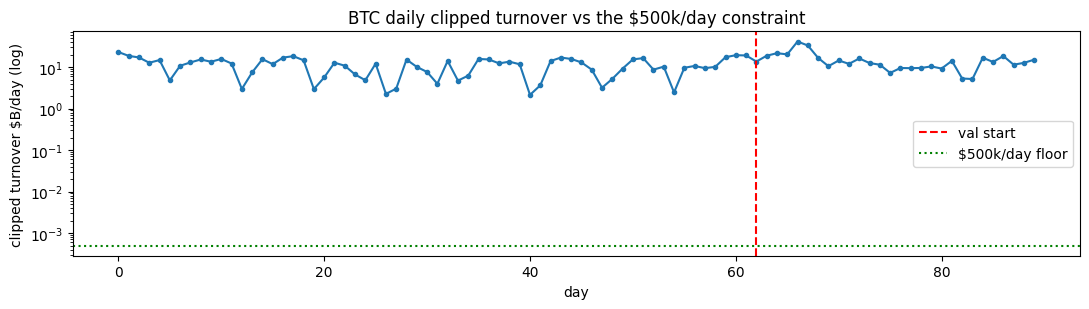

In [9]:
daily = eda.daily_clipped_turnover(f"{DATA_ROOT}/binance_trades/perp_{SYM}usdt.parquet")
share = eda.min_turnover_share(daily)
print(f"avg daily clipped turnover: ${share['avg_daily_clipped_turnover_usd'] / 1e9:.2f}B/day")
print(f"min share to keep (>= $500k/day): {share['min_share_to_keep']:.2e}")
print(f"=> we may filter up to {share['max_filtered_share'] * 100:.4f}% of clipped turnover")

d = daily.with_columns((pl.col("day") * 86400 - eda.TRAIN_START // 1_000_000 // 86400 * 86400).alias("x"))
day_idx = (daily["day"].to_numpy() - daily["day"].to_numpy()[0])
plt.figure(figsize=(11, 3.2))
plt.plot(day_idx, daily["clipped_turnover"].to_numpy() / 1e9, marker=".")
plt.axvline((eda.VAL_START - eda.TRAIN_START) / 1e6 / 86400, color="r", ls="--", label="val start")
plt.axhline(eda.MIN_TURNOVER_PER_DAY / 1e9, color="g", ls=":", label="$500k/day floor")
plt.yscale("log"); plt.ylabel("clipped turnover $B/day (log)"); plt.xlabel("day"); plt.legend()
plt.title("BTC daily clipped turnover vs the $500k/day constraint"); plt.tight_layout(); plt.show()

**Finding - the turnover constraint is effectively non-binding.** BTC trades ~$12B/day of
clipped turnover, so the $500k/day floor is ~4e-5 of it: we could keep as little as **0.004%**
of turnover and still satisfy the constraint. The binding limit is therefore the **score**, not
the volume kept - the filter is free to be aggressive in toxic regimes.

## Executive summary

| Question | Finding |
|---|---|
| **Data quality** | No NaNs / bad prices / bad sides / crossed books. Heavy duplicate timestamps and small time gaps are **market/feed features**, not corruption. Data is usable as-is. |
| **Markout** | Maker flow is near break-even in train but **toxic (negative PnL_all) in validation** at all horizons - a real **regime shift**; symmetric, heavy-tailed distribution that widens with tau. |
| **Liquidations / cascades** | Bursty **multi-venue cascades** (1s clustering finds hundreds; ~99% involve both venues; mostly one-sided forced selling). They are the mechanistic driver of the toxic markout. |
| **Turnover** | ~$12B/day clipped turnover ⇒ the $500k/day floor needs only ~**0.004%** kept; the constraint is essentially non-binding, the score is the real limit. |

**Implication for the filter.** Build features around windowed, +200 ms-shifted, combined
liquidation flow (notional, side imbalance, recency) plus BBO context, validate strictly
out-of-sample (train != validation), and filter aggressively during cascades - the turnover
budget allows it. That feature infrastructure is built in `task_2_features_shaw_team`.